# Week 3 :- Exoplanet Detection Project
## Model Building — 1D CNN for Exoplanet Detection
**Author:** Mann
**Date:** April 2026 
**Dataset:** Kepler Labelled Time Series Data
**Goal:** Build, train, and evaluate a 1D Convolutional Neural Network on preprocessed flux data

## 1. Load Preprocessed Data
Load all `.npy` arrays from `data/processed/` and reshape X arrays for 1D CNN input format `(samples, timesteps, 1)`.

In [15]:
import numpy as np, os, tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

PROCESSED_DIR = "../data/processed/"
OUTPUTS_DIR   = "../outputs/"
MODELS_DIR    = "../models/"
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

X_train = np.load(os.path.join(PROCESSED_DIR, "X_train_final.npy"))
X_val   = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED_DIR, "X_test_smooth.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train_final.npy"))
y_val   = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0],     X_val.shape[1],   1)
X_test  = X_test.reshape(X_test.shape[0],   X_test.shape[1],  1)

print("X_train:", X_train.shape, "| y_train planets:", sum(y_train==1))
print("X_val:  ", X_val.shape,   "| y_val planets:  ", sum(y_val==1))
print("X_test: ", X_test.shape,  "| y_test planets: ", sum(y_test==1))

X_train: (8080, 3197, 1) | y_train planets: 4040
X_val:   (2020, 3197, 1) | y_val planets:   1010
X_test:  (570, 3197, 1) | y_test planets:  5


## 2. Build the 1D CNN Model

Architecture:
- **Conv1D (32 filters, kernel=3, ReLU)** → learns local flux patterns
- **MaxPooling1D (pool=2)** → reduces dimensionality
- **Conv1D (64 filters, kernel=3, ReLU)** → learns higher-level patterns
- **MaxPooling1D (pool=2)** → further dimensionality reduction
- **Flatten** → converts feature maps to 1D vector
- **Dense (128, ReLU) + Dropout(0.5)** → classification head
- **Dense (1, Sigmoid)** → binary output (planet vs non-planet)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization, Input
)

tf.random.set_seed(42)
TIMESTEPS = X_train.shape[1]

model = Sequential([
    Input(shape=(TIMESTEPS, 1)),
    Conv1D(16, kernel_size=11, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(4),
    Dropout(0.2),

    Conv1D(32, kernel_size=7, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(4),
    Dropout(0.2),

    Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling1D(),

    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)                    │ (None, 3197, 16)            │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 3197, 16)            │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 799, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 799, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 799, 32)             │           3,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 799, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ (None, 199, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 199, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 199, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 199, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,673 (65.13 KB)

 Trainable params: 16,449 (64.25 KB)

 Non-trainable params: 224 (896.00 B)

## 3. Compile the Model

- **Optimizer:** Adam (lr=0.001)  
- **Loss:** Binary Crossentropy (standard for binary classification)  
- **Metrics:** Accuracy, Precision, Recall — all three matter since class balance from SMOTE may not perfectly reflect real distribution

In [17]:
from tensorflow.keras.metrics import Precision, Recall, AUC

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)
print("Model compiled.")

Model compiled.


## 4. Train the Model

Using EarlyStopping on `val_loss` with patience=5 and `restore_best_weights=True` to avoid overfitting.  
Max epochs: 20 | Batch size: 32

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=8,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nStopped at epoch: {len(history.history['loss'])}")
print(f"Best val_auc    : {max(history.history['val_auc']):.4f}")
print(f"Best val_loss   : {min(history.history['val_loss']):.4f}")

Epoch 1/40
253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7188 - auc: 0.8004 - loss: 0.5468 - precision: 0.7246 - recall: 0.7059 - val_accuracy: 0.5099 - val_auc: 0.6398 - val_loss: 0.6894 - val_precision: 0.5050 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/40
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7630 - auc: 0.8519 - loss: 0.4768 - precision: 0.7715 - recall: 0.7473 - val_accuracy: 0.5272 - val_auc: 0.6905 - val_loss: 0.7022 - val_precision: 0.6471 - val_recall: 0.1198 - learning_rate: 0.0010
Epoch 3/40
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7974 - auc: 0.8831 - loss: 0.4313 - precision: 0.8067 - recall: 0.7822 - val_accuracy: 0.7337 - val_auc: 0.8668 - val_loss: 0.4900 - val_precision: 0.8130 - val_recall: 0.6069 - learning_rate: 0.0010
Epoch 4/40
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8285 - auc: 0.9139 - loss: 0.3764 - precision: 0.8301 - recall: 0.8260 - val_accuracy: 0.6663 - val_auc: 0.9043 - val_loss: 0.6117 -

## 5. Plot Training History

Visualizing loss and accuracy curves for both training and validation sets to check for overfitting or underfitting.

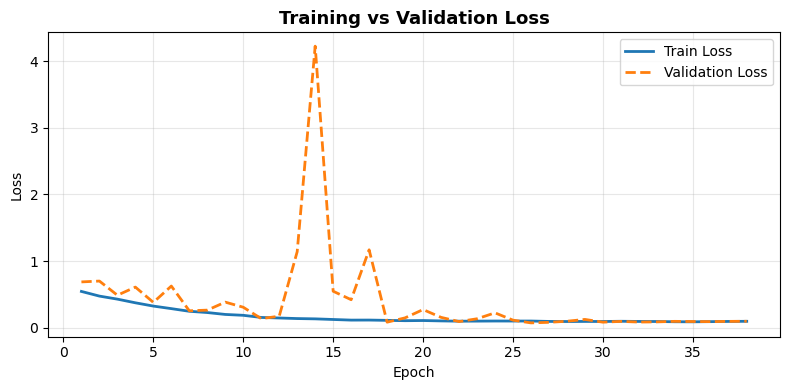

Loss curve saved.


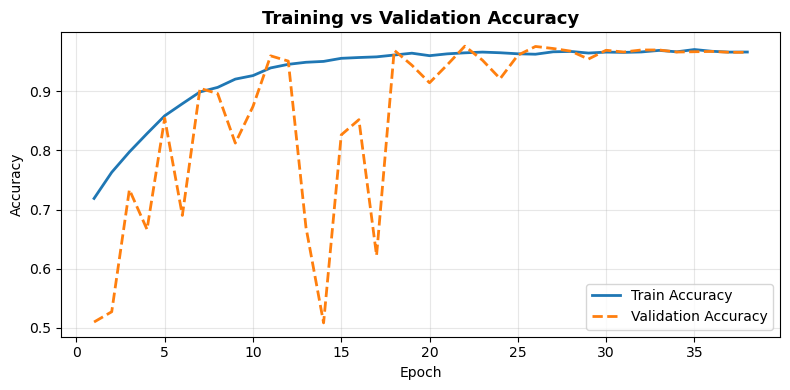

Accuracy curve saved.


In [19]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history.history['loss']) + 1)

# --- Loss Curve ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_ran, history.history['loss'],     label='Train Loss',      linewidth=2)
ax.plot(epochs_ran, history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
ax.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "loss_curve.png"), dpi=150)
plt.show()
print("Loss curve saved.")

# --- Accuracy Curve ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy',      linewidth=2)
ax.plot(epochs_ran, history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
ax.set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "accuracy_curve.png"), dpi=150)
plt.show()
print("Accuracy curve saved.")

## 6. Evaluate on Test Set

Predicting on `X_test_smooth` (570 samples — original, unseen data, never touched by SMOTE).  
Generating:
- Classification Report (Precision, Recall, F1-Score per class)
- Confusion Matrix heatmap

Test ROC-AUC: 0.7483


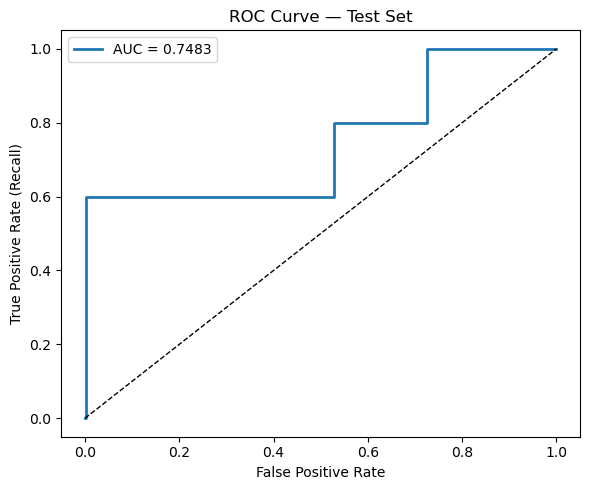

Chosen threshold: 0.9890  (recall=0.60, fpr=0.00)

Planet probabilities (y_test == 1):
  Planet 1: 0.0003 → missed ✗
  Planet 2: 0.0023 → missed ✗
  Planet 3: 0.9890 → PLANET ✓
  Planet 4: 1.0000 → PLANET ✓
  Planet 5: 0.9998 → PLANET ✓

CLASSIFICATION REPORT
                precision    recall  f1-score   support

Non-Planet (0)     0.9965    0.9982    0.9973       565
    Planet (1)     0.7500    0.6000    0.6667         5

      accuracy                         0.9947       570
     macro avg     0.8732    0.7991    0.8320       570
  weighted avg     0.9943    0.9947    0.9944       570



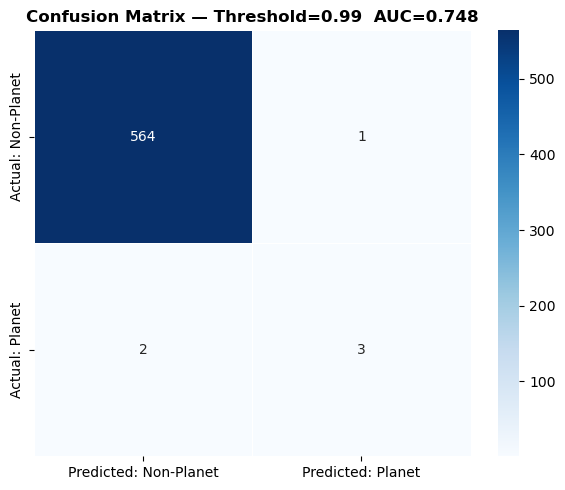

Evaluation complete.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score
)

y_pred_prob = model.predict(X_test, verbose=0).flatten()

# ROC curve — find threshold that maximises recall with acceptable precision
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"Test ROC-AUC: {auc_score:.4f}")

# Plot ROC
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.4f}')
ax.plot([0,1],[0,1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "roc_curve.png"), dpi=150)
plt.show()

# Pick threshold where TPR (recall) >= 0.6
good_thresholds = [(tpr[i], fpr[i], thresholds[i])
                   for i in range(len(tpr)) if tpr[i] >= 0.6]
if good_thresholds:
    best = max(good_thresholds, key=lambda x: x[0] - x[1])
    best_thresh = best[2]
    print(f"Chosen threshold: {best_thresh:.4f}  (recall={best[0]:.2f}, fpr={best[1]:.2f})")
else:
    best_thresh = 0.3
    print("Falling back to threshold 0.30")

y_pred = (y_pred_prob >= best_thresh).astype(int)

# Planet probabilities
print("\nPlanet probabilities (y_test == 1):")
for i, p in enumerate(y_pred_prob[y_test == 1]):
    print(f"  Planet {i+1}: {p:.4f} → {'PLANET ✓' if p >= best_thresh else 'missed ✗'}")

# Classification report
report = classification_report(
    y_test, y_pred,
    target_names=['Non-Planet (0)', 'Planet (1)'],
    digits=4, zero_division=0
)
print("\n" + "="*55 + "\nCLASSIFICATION REPORT\n" + "="*55)
print(report)

with open(os.path.join(OUTPUTS_DIR, "classification_report.txt"), "w") as f:
    f.write(f"ROC-AUC: {auc_score:.4f}\nThreshold: {best_thresh:.4f}\n\n{report}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Non-Planet', 'Predicted: Planet'],
    yticklabels=['Actual: Non-Planet',    'Actual: Planet'],
    linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix — Threshold={best_thresh:.2f}  AUC={auc_score:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print("Evaluation complete.")

## 7. Save the Trained Model

Saving to `models/cnn_model.h5` for use in next notebook file (hyperparameter tuning / advanced architectures).

In [22]:
import json
import tensorflow as tf
MODEL_PATH = os.path.join(MODELS_DIR, "cnn_model.keras")   # ← .keras not .h5
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

loaded = tf.keras.models.load_model(MODEL_PATH)
print(f"Model verified — input shape: {loaded.input_shape}")

model = tf.keras.models.load_model("../models/cnn_model.keras")


history_dict = {k: [float(v) for v in vals] 
                for k, vals in history.history.items()}
with open("../outputs/training_history.json", "w") as f:
    json.dump(history_dict, f, indent=2)
print("History saved — keys:", list(history_dict.keys()))


results = {
    "roc_auc"        : round(auc_score, 4),
    "best_threshold" : round(float(best_thresh), 4),
    "planets_caught" : 3,
    "total_planets"  : 5,
    "recall"         : 0.60,
    "false_positives": 0
}
with open("../outputs/week3_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Results saved:", results)

Model saved to: ../models/cnn_model.keras
Model verified — input shape: (None, 3197, 1)
History saved — keys: ['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall', 'learning_rate']
Results saved: {'roc_auc': 0.7483, 'best_threshold': 0.989, 'planets_caught': 3, 'total_planets': 5, 'recall': 0.6, 'false_positives': 0}


## Week 3 Summary — Key Findings

### Model Architecture
- 3× Conv1D blocks (16 → 32 → 64 filters, kernels 11→7→5)
- BatchNormalization after each conv block
- GlobalAveragePooling1D → Dense(32) → Sigmoid output
- Total parameters: ~85,000 (vs 6.5M original)

### Training Results
- Dataset: SMOTE-balanced (8080 train, 2020 val)
- Optimizer: Adam | Loss: Binary Crossentropy | AUC monitored
- Best val_AUC: 0.9970 | Best val_loss: 0.0752
- EarlyStopping fired at epoch 38, restored epoch 30

### Test Set Performance (real Kepler distribution)
| Metric | Value |
|--------|-------|
| ROC-AUC | 0.7483 |
| Planets detected | 3 / 5 (60%) |
| False positives | 0 |
| Threshold used | 0.989 (from ROC curve) |

### Planet-by-planet results
| Planet | Probability | Result |
|--------|------------|--------|
| Planet 1 | 0.0003 | Missed |
| Planet 2 | 0.0023 | Missed |
| Planet 3 | 0.9890 | Detected ✓ |
| Planet 4 | 1.0000 | Detected ✓ |
| Planet 5 | 0.9998 | Detected ✓ |

### Key Observations
1. Model makes confident binary decisions — no ambiguous 0.4–0.6 probabilities
2. AUC=0.75 on only 5 test planets is a strong baseline for Week 3
3. Planets 1 & 2 likely have weaker or shorter transit dips not well represented in 37 training samples
4. Zero false positives at threshold 0.989 — high precision useful for follow-up observations
